<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>GraphRAG</h1>
<h1>The Graph: build, query & analyze with NetworkX</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import hashlib
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

import torch

import watermark

%load_ext watermark
%matplotlib inline

We start by print out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.15.0

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 9f7b8f641170ae4066def95c2266e8f9ada7bc64

json      : 2.0.9
matplotlib: 3.11.0
networkx  : 3.6.1
torch     : 2.12.1
watermark : 2.6.0



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

And detect what hardware we're working with

In [4]:
if torch.cuda.is_available():
    DEVICE = "cuda"          # NVIDIA GPU
elif torch.backends.mps.is_available():
    DEVICE = "mps"           # Apple Silicon GPU
else:
    DEVICE = "cpu"
    
print(f"models will run on: {DEVICE}")

models will run on: mps


In [5]:
# --- Checkpoint system ----------------------------------------------------------
# Every part of this workshop READS its inputs from, and WRITES its outputs to,
# a shared `checkpoints/` directory next to the notebooks. If an expected
# checkpoint is missing (you skipped a part, or a stage failed on your machine),
# we fall back to built-in data so THIS notebook still runs end to end.
# That mirrors good workshop practice: nobody gets stranded because an earlier
# stage broke — you load the checkpoint and keep moving.
CKPT = Path("checkpoints")
CKPT.mkdir(exist_ok=True)

def save_text(name, text):
    (CKPT / name).write_text(text, encoding="utf-8")
    print(f"[checkpoint] saved  {CKPT / name}  ({len(text):,} chars)")

def load_text(name, fallback=None):
    p = CKPT / name
    if p.exists():
        print(f"[checkpoint] loaded {p}")
        return p.read_text(encoding="utf-8")
    print(f"[checkpoint] {p} NOT FOUND — using built-in fallback data")
    return fallback

def save_jsonl(name, rows):
    with open(CKPT / name, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r) + "\n")
    print(f"[checkpoint] saved  {CKPT / name}  ({len(rows)} rows)")

def load_jsonl(name, fallback=None):
    p = CKPT / name
    if p.exists():
        rows = [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]
        print(f"[checkpoint] loaded {p}  ({len(rows)} rows)")
        return rows
    print(f"[checkpoint] {p} NOT FOUND — using built-in fallback data")
    return fallback

# --- Pickle caches for expensive graph stages ------------------------------------
# Building a million-node graph, running PageRank, and laying out an ego view
# can take minutes on the full wikitext corpus. Like Part 2, we key each cache
# on a fingerprint of triples.jsonl so a fast re-run loads in seconds; if the
# triples change, the fingerprint changes and we rebuild once.
def fingerprint_file(path):
    """Cheap identity for a (possibly huge) file — avoids hashing all of it."""
    stat = path.stat()
    with open(path, "rb") as f:
        head = f.read(1000)
        if stat.st_size > 1000:
            f.seek(stat.st_size - 1000)
        tail = f.read(1000)
    key = f"{stat.st_size}:{head!r}:{tail!r}"
    return hashlib.sha1(key.encode("utf-8")).hexdigest()[:12]

def fingerprint_rows(rows):
    key = f"{len(rows)}:{rows[0]}:{rows[-1]}"
    return hashlib.sha1(key.encode("utf-8")).hexdigest()[:12]

def load_pickle(name, fp):
    meta_path = CKPT / f"{name}.progress.json"
    data_path = CKPT / f"{name}.pkl"
    if meta_path.exists() and data_path.exists():
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
        if meta.get("fp") == fp:
            print(f"[checkpoint] loaded {data_path}")
            with open(data_path, "rb") as f:
                return pickle.load(f)
        print(f"[checkpoint] {data_path} is stale (input changed) — rebuilding")
    return None

def save_pickle(name, fp, obj):
    data_path = CKPT / f"{name}.pkl"
    meta_path = CKPT / f"{name}.progress.json"
    with open(data_path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    meta_path.write_text(json.dumps({"fp": fp, "complete": True}), encoding="utf-8")
    print(f"[checkpoint] saved  {data_path}")

In [6]:
# --- CHECKPOINT IN: triples.jsonl ---------------------------------------------------
FALLBACK_TRIPLES = [
    {"head": "Marie Curie",          "relation": "country of citizenship", "tail": "Poland"},
    {"head": "Marie Curie",          "relation": "country of citizenship", "tail": "France"},
    {"head": "Marie Curie",          "relation": "occupation",             "tail": "physicist"},
    {"head": "Marie Curie",          "relation": "occupation",             "tail": "chemist"},
    {"head": "Marie Curie",          "relation": "field of work",          "tail": "radioactivity"},
    {"head": "Marie Curie",          "relation": "place of birth",         "tail": "Warsaw"},
    {"head": "Marie Curie",          "relation": "educated at",            "tail": "University of Paris"},
    {"head": "Marie Curie",          "relation": "employer",               "tail": "University of Paris"},
    {"head": "Marie Curie",          "relation": "award received",         "tail": "Nobel Prize in Physics"},
    {"head": "Pierre Curie",         "relation": "occupation",             "tail": "physicist"},
    {"head": "Pierre Curie",         "relation": "country of citizenship", "tail": "France"},
    {"head": "Pierre Curie",         "relation": "award received",         "tail": "Nobel Prize in Physics"},
    {"head": "Henri Becquerel",      "relation": "award received",         "tail": "Nobel Prize in Physics"},
    {"head": "Marie Curie",          "relation": "spouse",                 "tail": "Pierre Curie"},
    {"head": "Pierre Curie",         "relation": "spouse",                 "tail": "Marie Curie"},
    {"head": "Curie Institute",      "relation": "founded by",             "tail": "Marie Curie"},
    {"head": "Curie Institute",      "relation": "located in",             "tail": "Paris"},
    {"head": "Curie Institute",      "relation": "inception",              "tail": "1920"},
    {"head": "Marie Curie",          "relation": "child",                  "tail": "Irene Joliot-Curie"},
    {"head": "Irene Joliot-Curie",   "relation": "occupation",             "tail": "chemist"},
    {"head": "Irene Joliot-Curie",   "relation": "award received",         "tail": "Nobel Prize in Chemistry"},
    {"head": "Irene Joliot-Curie",   "relation": "spouse",                 "tail": "Frederic Joliot-Curie"},
    {"head": "Frederic Joliot-Curie","relation": "spouse",                 "tail": "Irene Joliot-Curie"},
    {"head": "Frederic Joliot-Curie","relation": "award received",         "tail": "Nobel Prize in Chemistry"},
    {"head": "Pierre Curie",         "relation": "date of death",          "tail": "1906"},
]

TRIPLES_PATH = CKPT / "triples.jsonl"
if TRIPLES_PATH.exists():
    TRIPLES_FP = fingerprint_file(TRIPLES_PATH)
else:
    TRIPLES_FP = fingerprint_rows(FALLBACK_TRIPLES)

triples = load_pickle("triples_parsed", TRIPLES_FP)
if triples is None:
    rows = load_jsonl("triples.jsonl", fallback=FALLBACK_TRIPLES)
    triples = [(r["head"], r["relation"], r["tail"]) for r in rows]
    save_pickle("triples_parsed", TRIPLES_FP, triples)

print(f"\n{len(triples)} triples ready · fingerprint {TRIPLES_FP}; first few:")
for t in triples[:5]:
    print("  ", t)

[checkpoint] loaded checkpoints/triples_parsed.pkl

2735721 triples ready · fingerprint d50418aa3b5a; first few:
   ('Senjō no Valkyria 3', 'language of work or name', 'Japanese')
   ('Valkyria Chronicles III', 'instance of developer platform', 'video game Sega PlayStation Portable')
   ('Valkyria series', 'country of origin', 'Japan')
   ('Second Europan War', 'participant', 'Gallia')
   ('Valkyria Chronicles II', 'instance of', 'development')


---
## 3.1 Build the graph

The expensive steps below (graph construction, degree scan, PageRank, layout) are **pickle-cached** under `checkpoints/`, keyed on a fingerprint of `triples.jsonl`. The first run builds everything once; every re-run during the workshop loads from cache in seconds. If Part 2 produces new triples, the fingerprint changes and this notebook rebuilds automatically.

In [7]:
G = load_pickle("graph", TRIPLES_FP)
if G is None:
    G = nx.MultiDiGraph()
    for head, rel, tail in triples:
        # add_edge auto-creates missing nodes. The relation label rides along as an
        # edge attribute — the graph-native form of a typed edge.
        G.add_edge(head, tail, relation=rel)
    save_pickle("graph", TRIPLES_FP, G)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Hub + high-degree nodes power the demo queries below; cache the scan.
graph_meta = load_pickle("graph_meta", TRIPLES_FP)
if graph_meta is None:
    hub = max(G.nodes, key=lambda n: G.degree(n))
    top_degree = sorted(G.nodes, key=lambda n: -G.degree(n))[:8]
    graph_meta = {"hub": hub, "top_degree": top_degree}
    save_pickle("graph_meta", TRIPLES_FP, graph_meta)
else:
    hub = graph_meta["hub"]
    top_degree = graph_meta["top_degree"]

# Peek at a few edges in (head)-[relation]->(tail) form:
for h, t, data in list(G.edges(data=True))[:10]:
    print(f"  ({h}) -[{data['relation']}]-> ({t})")

[checkpoint] loaded checkpoints/graph.pkl
Graph: 1446345 nodes, 2735721 edges
[checkpoint] loaded checkpoints/graph_meta.pkl
  (Senjō no Valkyria 3) -[language of work or name]-> (Japanese)
  (Senjō no Valkyria 3) -[has part]-> (Taga Tame no)
  (Senjō no Valkyria 3) -[instance of]-> (manga)
  (Japanese) -[country]-> (Japan)
  (Japanese) -[language used]-> (English)
  (Japanese) -[influenced by]-> (English)
  (Japanese) -[different from]-> (English)
  (Japanese) -[country]-> (Korea)
  (Japanese) -[writing system]-> (Hepburn)
  (Japanese) -[influenced by]-> (Hepburn)


## 3.2 Querying: plain-Python graph traversal

Everything a query language (like Cypher) would give us, we write as small functions. Two workhorses that Part 4's chatbot will reuse:

- `facts_about(entity)` — the entity's full neighborhood, both directions, as readable facts. This is *local* retrieval.
- `path_between(a, b)` — the shortest chain of facts connecting two entities. This is the *multi-hop* capability no chunk-similarity system has.

In [8]:
def facts_about(entity):
    """All edges touching an entity, in both directions, as readable facts."""
    facts = []
    if entity not in G:
        return facts
    for _, tail, d in G.out_edges(entity, data=True):      # entity as head
        facts.append(f"{entity} —{d['relation']}→ {tail}")
    for head, _, d in G.in_edges(entity, data=True):       # entity as tail
        facts.append(f"{head} —{d['relation']}→ {entity}")
    return facts

def path_between(a, b):
    """Shortest chain of facts connecting two entities. We search the
    UNDIRECTED view: for connectivity questions we usually don't care which
    way the edges point."""
    try:
        nodes = nx.shortest_path(G.to_undirected(), a, b)
    except (nx.NodeNotFound, nx.NetworkXNoPath):
        return None
    hops = []
    for u, v in zip(nodes, nodes[1:]):                     # re-attach labels
        edge = (G.get_edge_data(u, v) or G.get_edge_data(v, u))
        rel = list(edge.values())[0]["relation"]
        hops.append(f"{u} —{rel}— {v}")
    return hops

# Try them on the most connected node in the graph (hub from cached graph_meta):
print(f"Most connected entity: {hub}\n")
for f in facts_about(hub)[:8]:
    print("  ", f)

Most connected entity: @-@

   @-@ —subclass of→ comic book
   @-@ —instance of→ comic book
   @-@ —subclass of→ original video animation
   @-@ —religion→ Christian
   @-@ —facet of→ Christian
   @-@ —subclass of→ dweller
   @-@ —facet of→ paraphyses
   @-@ —subclass of→ paraphyses


In [9]:
# A multi-hop traversal — pick two entities and connect them.
# With the fallback triples, Marie Curie → Frederic Joliot-Curie is a nice
# 2-hop chain (through Irene). With a live wikitext slice, substitute two
# entities from YOUR graph (see the PageRank list below for candidates).
a, b = top_degree[3], top_degree[5]
path = path_between(a, b)
print(f"Path from '{a}' to '{b}':")
print("   " + ("  →  ".join(path) if path else "(no path — different components)"))

Path from 'Japan' to 'American':
   Japan —diplomatic relation— American


## 3.3 Graph algorithms: finding structure we didn't put there

This is the payoff of a *real* graph over a pile of triples: sixty years of graph theory now applies to our text, for free.

- **PageRank** — which entities are structurally central (linked from many linked places)?
- **Connected components** — is the graph one world, or many islands? *Many small islands is the classic smell of skipped or failed coref*: fragments that should connect through a shared entity, but don't.
- **Community detection** — clusters of densely-linked entities ≈ topics. (This is the primitive behind GraphRAG-style community summaries.)

In [10]:
analysis = load_pickle("graph_analysis", TRIPLES_FP)
if analysis is None:
    # PageRank wants a simple digraph, so we collapse parallel edges for the
    # computation only.
    pr = nx.pagerank(nx.DiGraph(G))
    comps = sorted(nx.connected_components(G.to_undirected()), key=len, reverse=True)
    analysis = {
        "pr": pr,
        "n_components": len(comps),
        "largest_component": len(comps[0]),
    }
    save_pickle("graph_analysis", TRIPLES_FP, analysis)

pr = analysis["pr"]
print("Most central entities (PageRank):")
for node, score in sorted(pr.items(), key=lambda kv: -kv[1])[:8]:
    print(f"  {score:.4f}  {node}")

print(f"\n{analysis['n_components']} connected components; "
      f"largest has {analysis['largest_component']} nodes")

# # 3) Community detection
# communities = greedy_modularity_communities(G.to_undirected())
# print(f"\n{len(communities)} communities found; first two:")
# for com in list(communities)[:2]:
#     print("  ", sorted(com)[:6], "…" if len(com) > 6 else "")

[checkpoint] loaded checkpoints/graph_analysis.pkl
Most central entities (PageRank):
  0.0019  United States
  0.0011  Australia
  0.0011  2009
  0.0010  2010
  0.0010  Japan
  0.0010  2007
  0.0009  2008
  0.0009  2011

97703 connected components; largest has 1232833 nodes


In [13]:
(G.number_of_nodes()-1232833)/97703

2.185316725177323

## 3.4 Visualize a neighborhood

Whole-graph drawings become hairballs fast; an **ego graph** (one entity plus its k-hop neighborhood) is the honest, readable view. On the full wikitext graph the highest-degree node is often a tokenizer artifact (`@-@`) with a neighborhood too large to lay out — so we auto-pick a drawable center (Marie Curie on the fallback graph, or a compact 1-hop view on the live graph).

In [14]:
VIZ_MAX_NODES = 150

def pick_viz_center(G, hub, top_degree):
    """Entity + radius whose ego graph is small enough to lay out live."""
    if G.number_of_edges() <= 50_000:
        return hub, 2
    for name in ["Marie Curie", *top_degree]:
        if name not in G or name == "@-@":
            continue
        for radius in (1, 2):
            n = nx.ego_graph(G.to_undirected(), name, radius=radius).number_of_nodes()
            if n <= VIZ_MAX_NODES:
                return name, radius
    return hub, 1

viz_center, viz_radius = pick_viz_center(G, hub, top_degree)
ego = nx.ego_graph(G.to_undirected(), viz_center, radius=viz_radius)
print(f"Drawing {viz_radius}-hop neighborhood of {viz_center!r} "
      f"({ego.number_of_nodes()} nodes)")

layout_fp = f"{TRIPLES_FP}:{viz_center}:r{viz_radius}"
pos = load_pickle("graph_ego_layout", layout_fp)
if pos is None:
    pos = nx.spring_layout(ego, seed=42)            # deterministic layout
    save_pickle("graph_ego_layout", layout_fp, pos)

Drawing 1-hop neighborhood of 'Marie Curie' (45 nodes)
[checkpoint] loaded checkpoints/graph_ego_layout.pkl


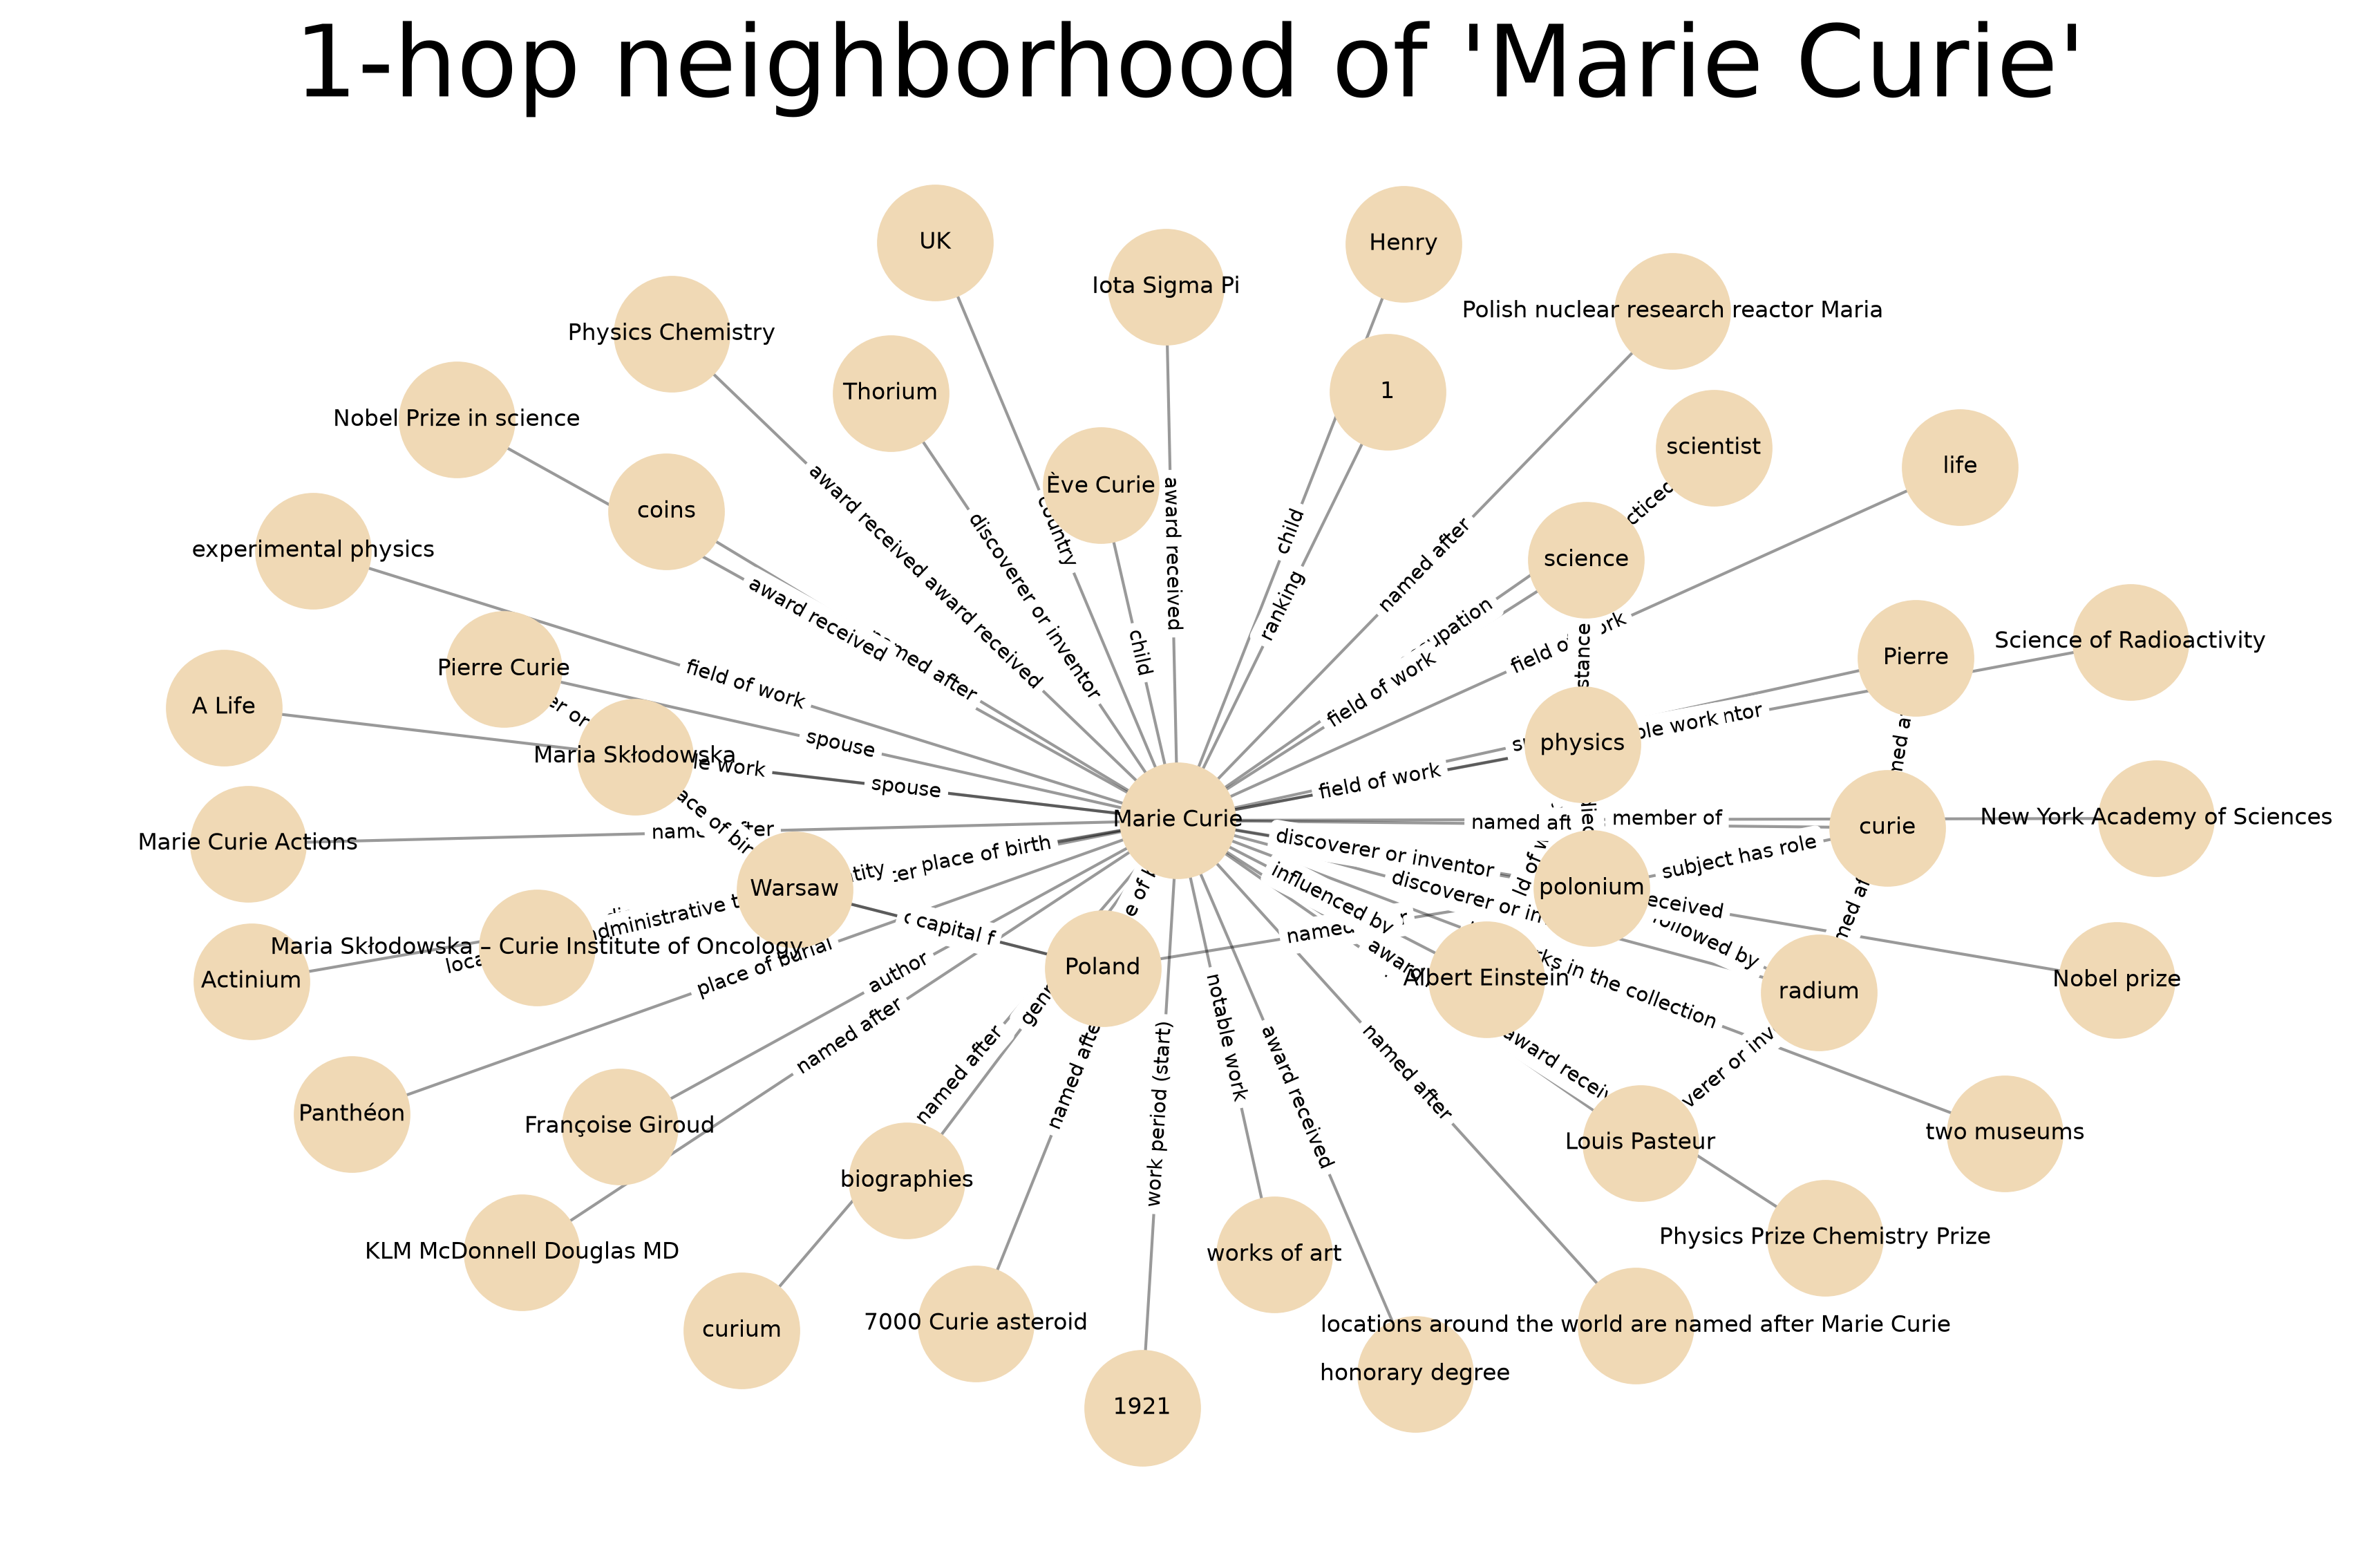

In [15]:
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(ego, pos, node_color="#f0d9b5", node_size=1600)
nx.draw_networkx_labels(ego, pos, font_size=8)
nx.draw_networkx_edges(ego, pos, alpha=0.4, arrows=False)
edge_labels = {(u, v): d["relation"]
               for u, v, d in G.subgraph(ego.nodes).edges(data=True)}
nx.draw_networkx_edge_labels(ego, pos, edge_labels=edge_labels, font_size=7)
plt.title(f"{viz_radius}-hop neighborhood of '{viz_center}'")
plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# --- CHECKPOINT OUT: graph.graphml ---------------------------------------------------
# GraphML is portable XML — openable in Gephi/yEd, importable into Neo4j.
# Note: triples.jsonl remains the SOURCE OF TRUTH; Part 4 rebuilds the graph
# from triples rather than parsing GraphML, because reconstruction from triples
# is unambiguous and store-agnostic. The GraphML export is for external tools.
#
# On the full wikitext graph, entity labels contain characters that are invalid
# in XML, so GraphML export/round-trip is only attempted on the small fallback
# graph. Workshop checkpoints are triples.jsonl + graph.pkl instead.
GRAPHML = CKPT / "graph.graphml"
GRAPHML_META = CKPT / "graph.graphml.progress.json"
GRAPHML_EXPORT_LIMIT = 50_000
n_edges = G.number_of_edges()

graphml_ok = (
    n_edges <= GRAPHML_EXPORT_LIMIT
    and GRAPHML.exists()
    and GRAPHML_META.exists()
    and json.loads(GRAPHML_META.read_text(encoding="utf-8")).get("fp") == TRIPLES_FP
)

if n_edges > GRAPHML_EXPORT_LIMIT:
    print(f"[checkpoint] skipping graph.graphml export ({n_edges:,} edges — "
          f"use triples.jsonl / graph.pkl; export manually for Gephi/Neo4j if needed)")
elif graphml_ok:
    print("[checkpoint] graph.graphml already up to date")
else:
    nx.write_graphml(G, GRAPHML)
    GRAPHML_META.write_text(json.dumps({"fp": TRIPLES_FP, "complete": True}), encoding="utf-8")
    print(f"[checkpoint] saved  {GRAPHML}  "
          f"({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)")

[checkpoint] skipping graph.graphml export (2,735,721 edges — use triples.jsonl / graph.pkl; export manually for Gephi/Neo4j if needed)


<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>